# Traffic Sign Recognition Using Convolutional Neural Networks (CNN)

A deep learning project that classifies traffic sign images using a Convolutional Neural Network (CNN) and the German Traffic Sign Recognition Benchmark (GTSRB).

## Objectives
- Explore the GTSRB traffic sign dataset.
- Preprocess and augment images.
- Build and train a CNN for multi-class classification.
- Evaluate the model with accuracy, precision, recall, F1-score, and a confusion matrix.
- Generate sample predictions.


## 1. Import Libraries and Check the Environment

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


## 2. Load the GTSRB Dataset

GTSRB (German Traffic Sign Recognition Benchmark) is a multi-class traffic sign recognition dataset. Torchvision provides a built-in `GTSRB` dataset class with train and test splits and automatic downloading.

The original training set is split into training and validation data, while the separate test set is reserved for final evaluation.


In [ ]:
data_dir = "/content/data"

train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214),
                         (0.2724, 0.2608, 0.2669))
])

eval_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214),
                         (0.2724, 0.2608, 0.2669))
])

full_train_aug = datasets.GTSRB(root=data_dir, split="train",
                                transform=train_transform, download=True)
full_train_eval = datasets.GTSRB(root=data_dir, split="train",
                                 transform=eval_transform, download=False)
test_dataset = datasets.GTSRB(root=data_dir, split="test",
                              transform=eval_transform, download=True)

print("Training images:", len(full_train_aug))
print("Test images:", len(test_dataset))
print("Number of classes: 43")


100%|██████████| 187M/187M [00:22<00:00, 8.24MB/s]
100%|██████████| 89.0M/89.0M [00:13<00:00, 6.74MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 182kB/s]


Training images: 26640
Test images: 12630
Number of classes: 43


## 3. Create Training and Validation Sets

In [ ]:
train_size = int(0.85 * len(full_train_aug))
indices = torch.randperm(len(full_train_aug), generator=torch.Generator().manual_seed(SEED)).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(full_train_aug, train_indices)
val_dataset = Subset(full_train_eval, val_indices)

batch_size = 128
workers = 2

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=workers, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=workers, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=workers, pin_memory=torch.cuda.is_available())

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))


Training images: 22644
Validation images: 3996
Test images: 12630


## 4. Visualize Sample Traffic Signs

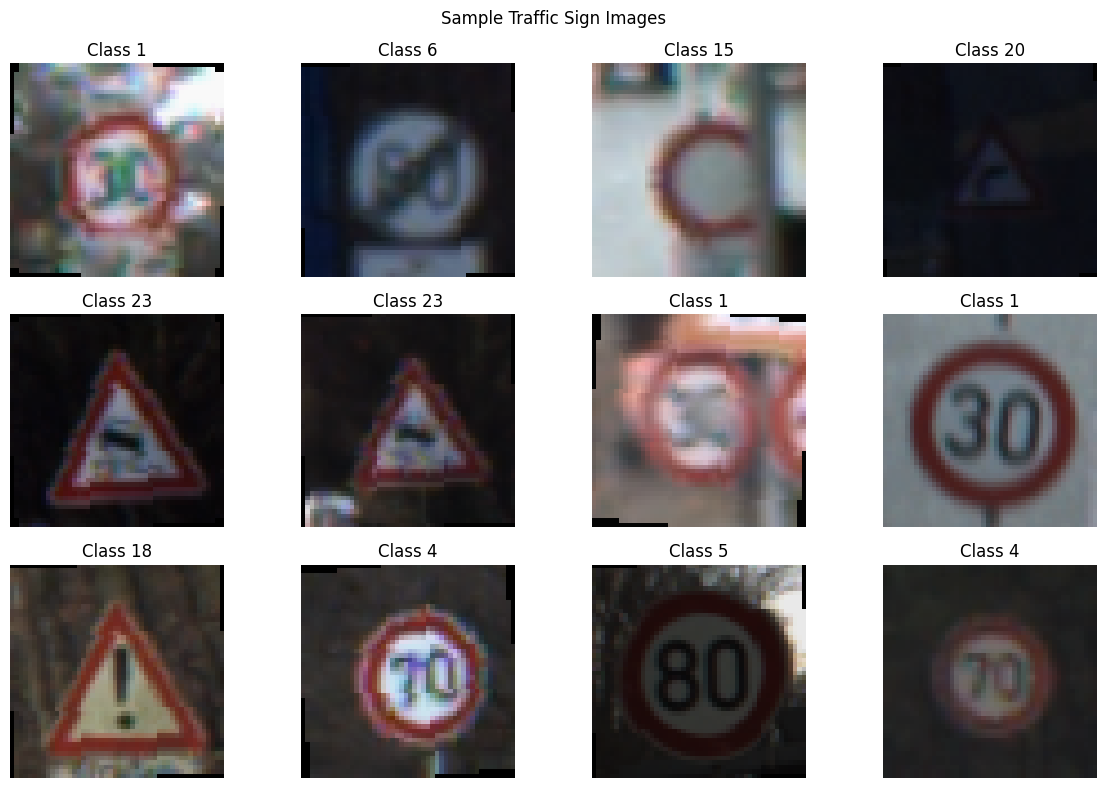

In [ ]:
mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1)
std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(12):
    img = (images[i].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
    ax = plt.subplot(3, 4, i + 1)
    ax.imshow(img)
    ax.set_title(f"Class {labels[i].item()}")
    ax.axis("off")
plt.suptitle("Sample Traffic Sign Images")
plt.tight_layout()
plt.show()


## 5. Build the CNN Model

In [ ]:
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = TrafficSignCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)


TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=2

## 6. Train the CNN

Five epochs are used for a practical Colab run. A GPU runtime is recommended.


In [ ]:
num_epochs = 5
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    model.eval()
    total_loss = 0.0
    correct = total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / total
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/5 | Train Loss: 1.9451 | Train Acc: 0.4362 | Val Loss: 0.6372 | Val Acc: 0.8258
Epoch 2/5 | Train Loss: 0.6143 | Train Acc: 0.8036 | Val Loss: 0.1932 | Val Acc: 0.9482
Epoch 3/5 | Train Loss: 0.3224 | Train Acc: 0.9001 | Val Loss: 0.1071 | Val Acc: 0.9662
Epoch 4/5 | Train Loss: 0.2094 | Train Acc: 0.9345 | Val Loss: 0.0549 | Val Acc: 0.9890
Epoch 5/5 | Train Loss: 0.1701 | Train Acc: 0.9459 | Val Loss: 0.0370 | Val Acc: 0.9922


## 7. Plot Training and Validation Performance

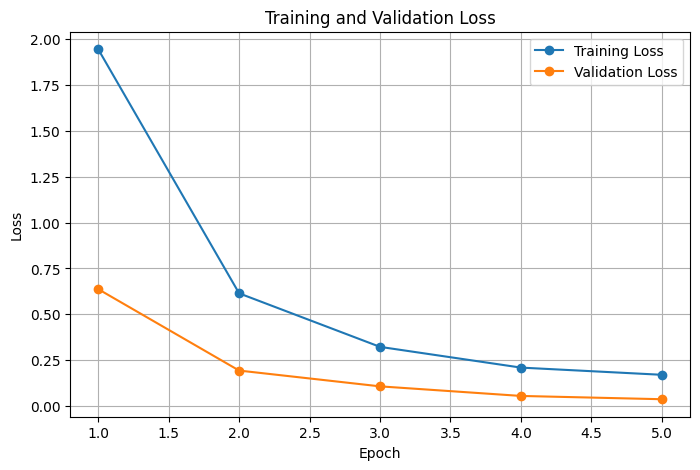

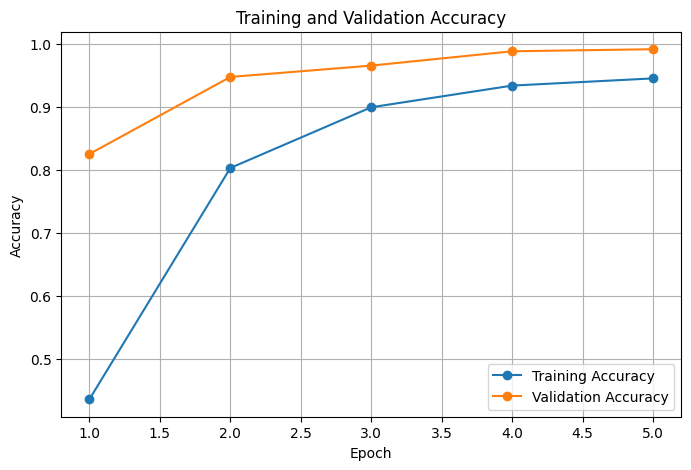

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 8. Evaluate the CNN on the Test Set

In [ ]:
model.eval()
all_predictions, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_predictions.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = (all_predictions == all_labels).mean()
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, zero_division=0))


Test Accuracy: 0.9519

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        60
           1       0.99      0.97      0.98       720
           2       0.98      0.99      0.98       750
           3       0.90      0.95      0.93       450
           4       0.96      0.98      0.97       660
           5       0.85      0.96      0.90       630
           6       0.97      0.93      0.95       150
           7       0.97      0.83      0.89       450
           8       0.93      0.89      0.91       450
           9       1.00      0.98      0.99       480
          10       1.00      0.98      0.99       660
          11       0.90      0.98      0.94       420
          12       0.96      0.96      0.96       690
          13       0.95      1.00      0.97       720
          14       0.97      0.99      0.98       270
          15       0.94      0.98      0.96       210
          16       0.99      0.97  

## 9. Confusion Matrix

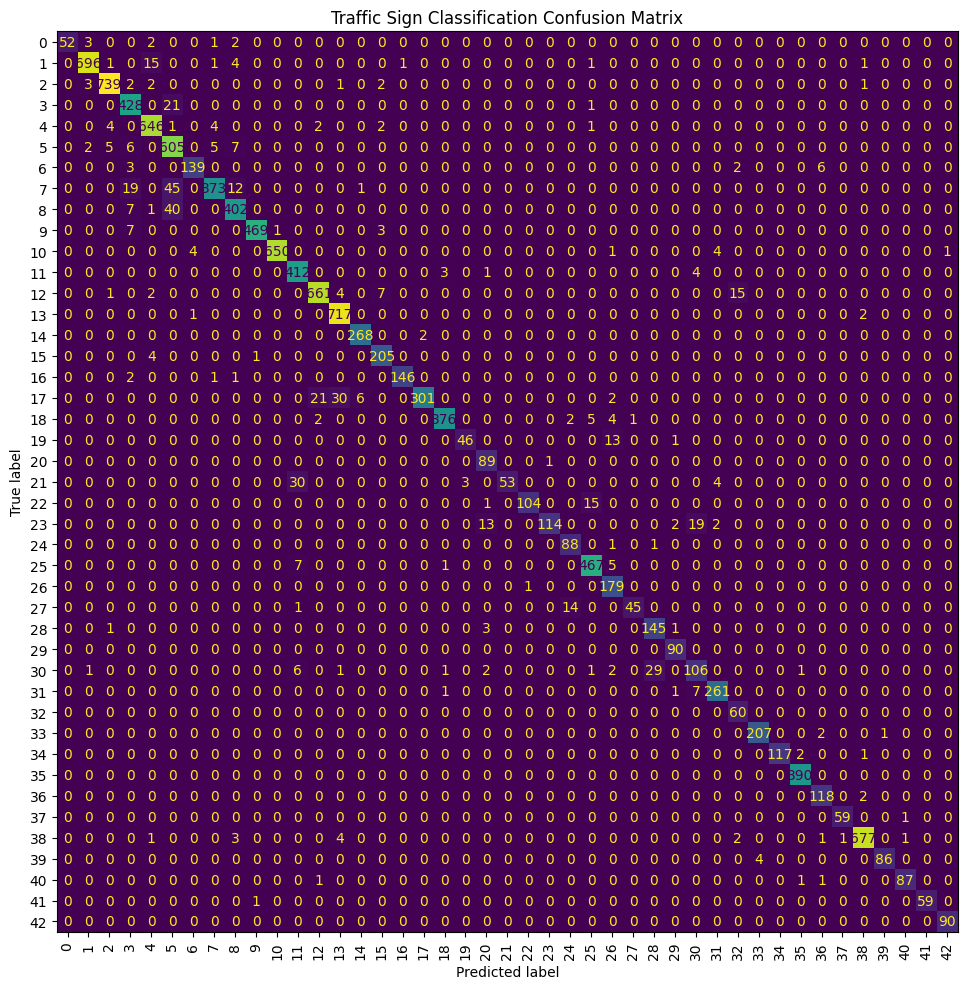

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    ax=ax, colorbar=False, xticks_rotation="vertical"
)
plt.title("Traffic Sign Classification Confusion Matrix")
plt.tight_layout()
plt.show()


## 10. Sample Predictions

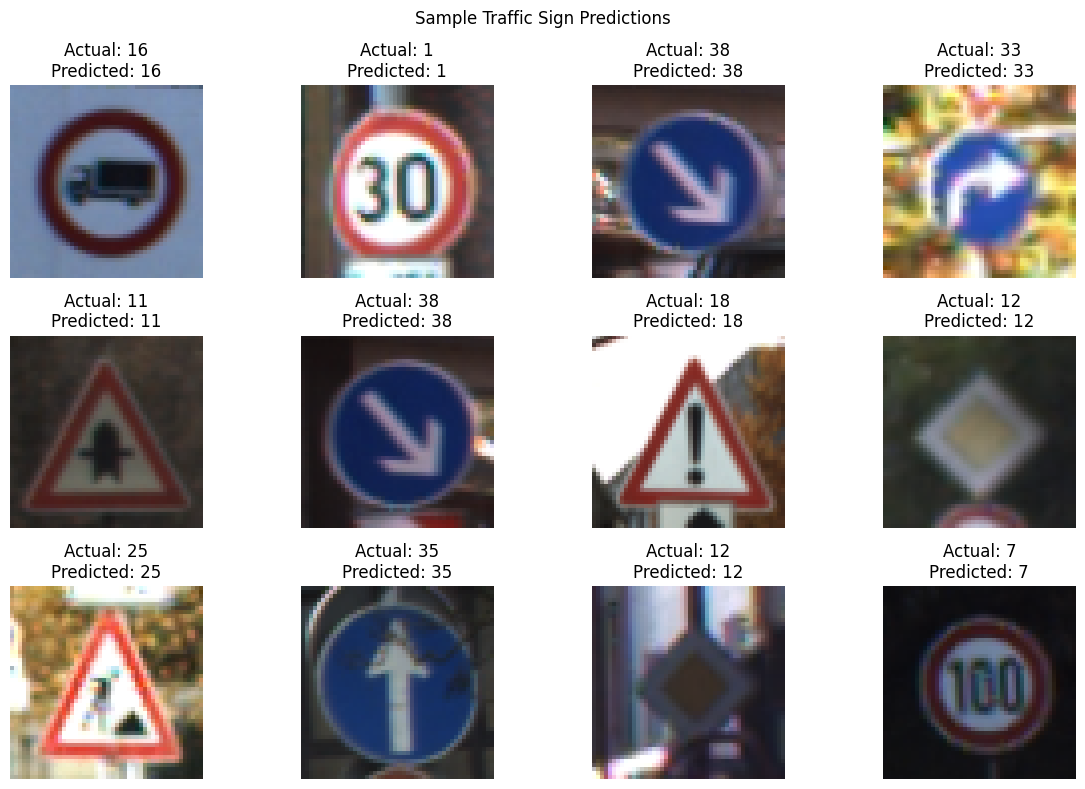

In [ ]:
sample_images, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_predictions = model(sample_images.to(device)).argmax(1).cpu()

plt.figure(figsize=(12, 8))
for i in range(12):
    img = (sample_images[i].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
    ax = plt.subplot(3, 4, i + 1)
    ax.imshow(img)
    ax.set_title(f"Actual: {sample_labels[i].item()}\nPredicted: {sample_predictions[i].item()}")
    ax.axis("off")
plt.suptitle("Sample Traffic Sign Predictions")
plt.tight_layout()
plt.show()


## 11. Key Findings and Conclusion

The CNN learns visual patterns such as shape, color, and local image features to classify traffic signs into multiple categories.

The project demonstrates a complete deep learning workflow for image classification, from preprocessing and augmentation to CNN training and evaluation.

### Key points
- Images were resized and normalized before training.
- Data augmentation was applied to training images.
- A CNN with convolution, pooling, batch normalization, and dropout was trained.
- Training and validation performance were monitored.
- Final performance was evaluated on a separate test set.
- A confusion matrix was used to identify classes that are harder to distinguish.

### Future Improvements
- Train for more epochs with early stopping.
- Use transfer learning with a pretrained CNN.
- Tune the learning rate, batch size, and architecture.
- Apply stronger data augmentation.
- Deploy the model for real-time traffic sign recognition.


## 12. Dataset and References

This project uses the **German Traffic Sign Recognition Benchmark (GTSRB)** through the `torchvision.datasets.GTSRB` interface.

References:
- GTSRB: https://benchmark.ini.rub.de/
- Torchvision GTSRB documentation: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.GTSRB.html

The dataset is downloaded automatically when the notebook is run with internet access.
